In [ ]:

import os
import json
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import os

print(os.listdir())

['.config', 'archive.zip', 'sample_data']


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("tarot_dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("tarot_dataset"))

['cards', 'tarot-images.json']


In [ ]:
with open("tarot_dataset/tarot-images.json","r") as file:
    data = json.load(file)

df = pd.DataFrame(data["cards"])

In [ ]:
df.head()


,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]","{'light': ['Freeing yourself from limitation',...",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]","{'light': ['Taking appropriate action', 'Recei...",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",{'light': ['Listening to your feelings and int...,The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]","{'light': ['Nurturing yourself and others', 'B...",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]","{'light': ['Exercising authority', 'Defining l...",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   meanings            78 non-null     object
 8   Archetype           22 non-null     object
 9   Hebrew Alphabet     22 non-null     object
 10  Numerology          62 non-null     object
 11  Elemental           38 non-null     object
 12  Mythical/Spiritual  22 non-null     object
 13  Questions to Ask    78 non-null     object
 14  Astrology           40 non-null     object
 15  Affirmation         56 non-null     object
dtypes: object(16)
memory usage: 

In [ ]:
df.isnull().sum()

,0
name,0
number,0
arcana,0
suit,0
img,0
fortune_telling,0
keywords,0
meanings,0
Archetype,56
Hebrew Alphabet,56


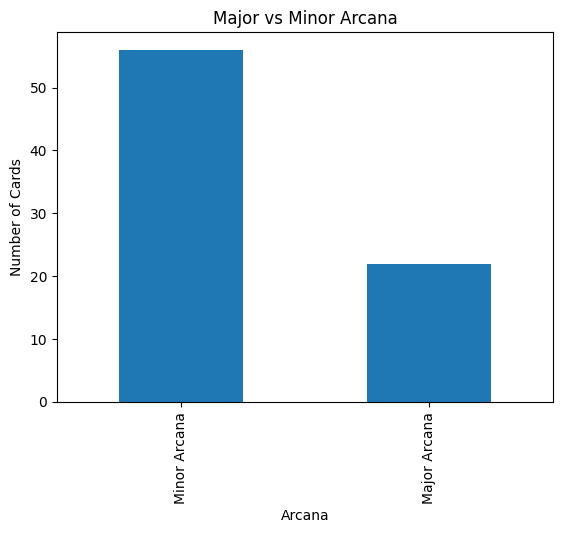

In [ ]:
df["arcana"].value_counts().plot(kind="bar")

plt.title("Major vs Minor Arcana")
plt.xlabel("Arcana")
plt.ylabel("Number of Cards")
plt.show()

In [ ]:
image_count = len(os.listdir("tarot_dataset/cards"))

print("Total Images:", image_count)

Total Images: 78


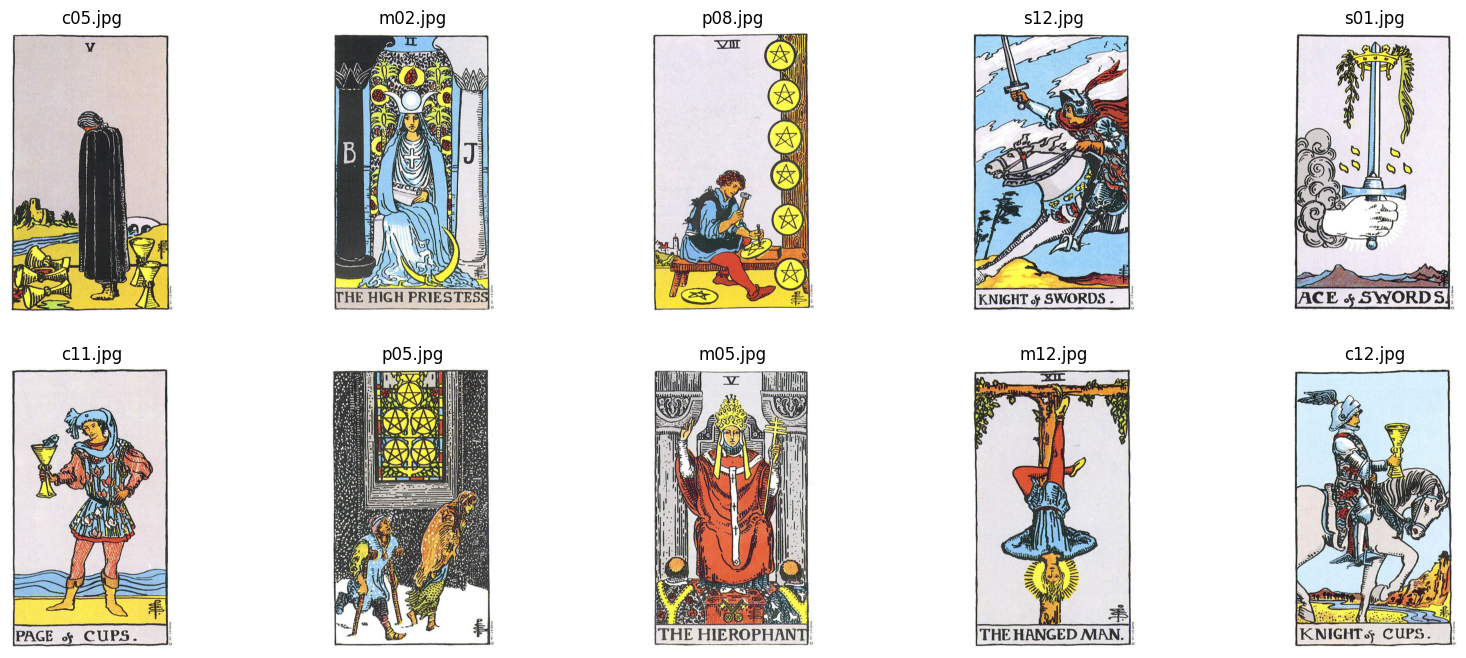

In [ ]:
image_paths=[]

for file in os.listdir("tarot_dataset/cards"):
    if file.endswith(".jpg"):
        image_paths.append(os.path.join("tarot_dataset/cards",file))

sample=random.sample(image_paths,10)

plt.figure(figsize=(20,8))

for i,path in enumerate(sample):
    img=Image.open(path)
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(os.path.basename(path))
    plt.axis("off")

plt.show()

# Summmary

The Exploratory Data Analysis (EDA) of the Tarot dataset helped me understand the overall structure and contents of the dataset. During the analysis, I explored the dataset by extracting the files, examining the folder structure, loading the JSON data, and understanding the different attributes available for each tarot card. I also checked the dataset information, identified missing values, analyzed the distribution of Major and Minor Arcana cards, counted the total number of images, and displayed sample images for visual inspection.

From this EDA, I learned that the dataset is well-structured and contains both image data and detailed information about each tarot card. The analysis gave me a better understanding of how the data is organized and highlighted the importance of exploring a dataset before building any machine learning model. Overall, this EDA provided a strong foundation for the next stages of the project, including data preprocessing, feature extraction, and model development.

In [38]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
from google.colab import files

uploaded = files.upload()

Saving hands.zip to hands.zip


In [5]:
import zipfile

with zipfile.ZipFile("hands.zip", "r") as zip_ref:
    zip_ref.extractall("hands")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [13]:
for root, dirs, files in os.walk("hands"):
    print(f"Folder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Number of files: {len(files)}")
    print("-"*50)

Folder: hands
Subfolders: ['Hands', 'images']
Number of files: 1
--------------------------------------------------
Folder: hands/Hands
Subfolders: []
Number of files: 0
--------------------------------------------------
Folder: hands/images
Subfolders: []
Number of files: 11076
--------------------------------------------------


In [39]:
print(os.listdir("hands"))

['HandInfo.csv', 'Hands', 'images']


In [40]:
df = pd.read_csv("hands/HandInfo.csv")

In [41]:
df.head()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


In [31]:
df.isnull().sum()

,0
id,0
age,0
gender,0
skinColor,0
accessories,0
nailPolish,0
aspectOfHand,0
imageName,0
irregularities,0


In [44]:
image_paths=[]

for file in os.listdir("hands/images"):
    if file.lower().endswith((".jpg",".jpeg",".png")):
        image_paths.append(os.path.join("hands/images",file))

print("Total Images:",len(image_paths))

Total Images: 11076


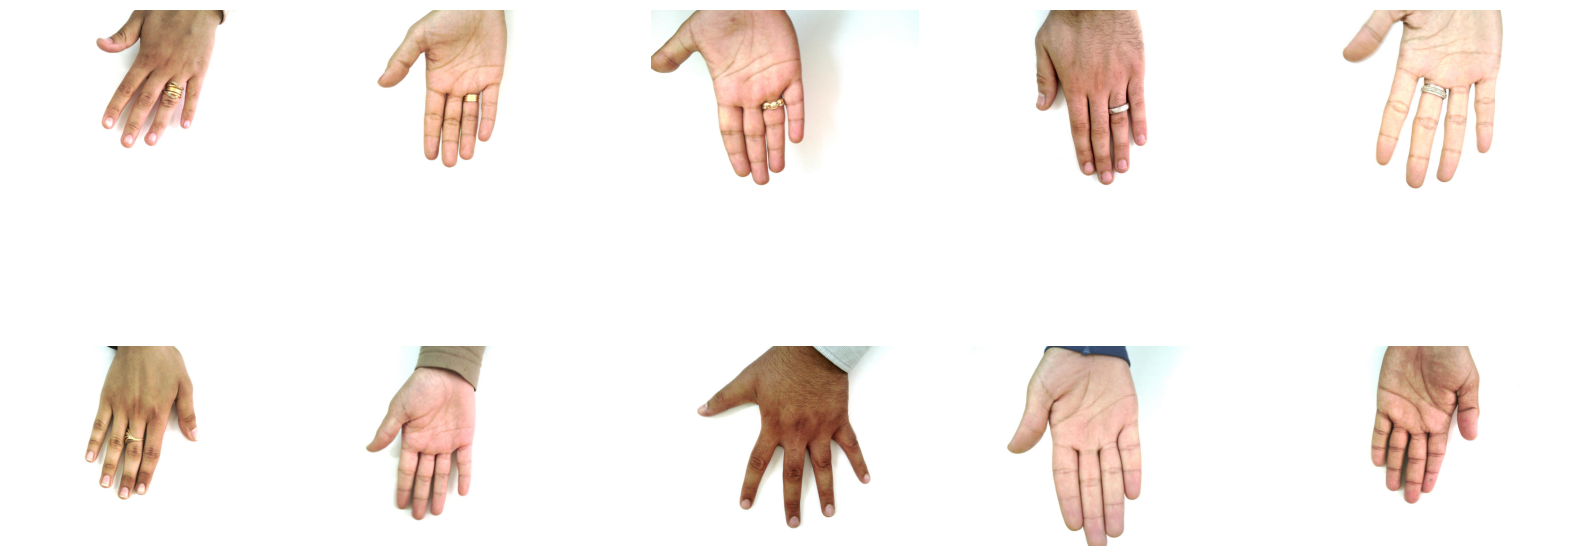

In [45]:
sample=random.sample(image_paths,10)

plt.figure(figsize=(20,8))

for i,path in enumerate(sample):
    img=Image.open(path)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [35]:
img=Image.open(image_paths[0])

print("Image Size:",img.size)
print("Image Mode:",img.mode)

Image Size: (1600, 1200)
Image Mode: RGB


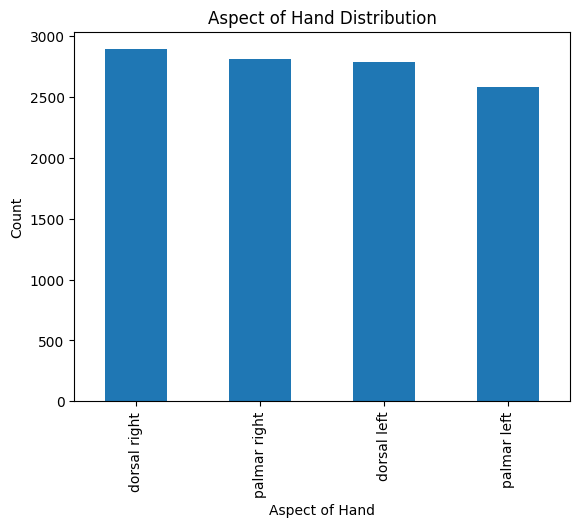

In [46]:
df["aspectOfHand"].value_counts().plot(kind="bar")

plt.title("Aspect of Hand Distribution")
plt.xlabel("Aspect of Hand")
plt.ylabel("Count")

plt.show()

# Conclusion

In this Exploratory Data Analysis (EDA), I explored the Hands and Palm Images dataset to understand its structure and contents. I loaded the dataset information from the CSV file and examined the available attributes such as age, gender, skin color, accessories, nail polish, hand aspect, image name, and irregularities. I also checked the dataset information, verified that there were no significant missing values, counted the total number of images, and displayed sample images to ensure that the dataset was loaded correctly. Finally, I analyzed the distribution of different hand aspects to understand the variety of hand images available in the dataset.

From this analysis, I gained a clear understanding of how the dataset is organized and what information it provides. The EDA helped me become familiar with both the metadata and the hand images, giving me a strong foundation for the next stages of the project, such as image preprocessing, feature extraction, and model development.